In [13]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import numpy as np

In [14]:
exp_utils_path = pathlib.Path("../../../../src/exploration/exp_utils")
sys.path.insert(0, str(exp_utils_path.resolve()))
from explorationUtils import ExplorationCube

In [15]:
folders = pathlib.Path(".").glob("*")
folders = [el for el in folders if el.is_dir() and str(el)[0] != "."]
folders

[PosixPath('max-p_100_n-layers_-1'), PosixPath('max-p_-1_n-layers_-1')]

In [16]:
folder_to_dfs_map = dict()
for folder in folders:
    folder_to_dfs_map[str(folder)] = dict()
    folder_to_dfs_map[str(folder)]["exp-error"] = pd.read_csv(folder / "exp-error-complete.txt", delimiter=";")
    folder_to_dfs_map[str(folder)]["test-error"] = pd.read_csv(folder / "test-error-complete.txt")
    folder_to_dfs_map[str(folder)]["times"] = pd.read_csv(folder / "times-complete.txt")

## Comparando performance do modelo

In [17]:
num_its = len(test_error_df)
print(f"num its: {num_its}")

num its: 24


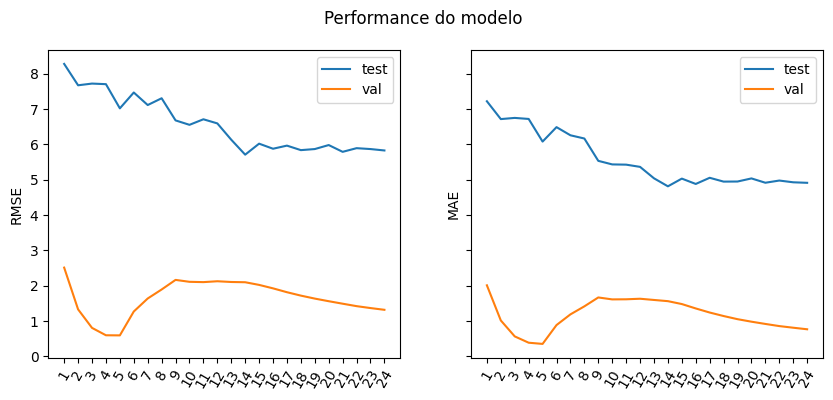

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 4))

label_rotation = 60

axs[0].plot(range(num_its),test_error_df['RMSE'], label="test")
axs[0].plot(range(num_its),exp_error_df['RMSE'], label="val")
axs[0].set_ylabel("RMSE")
axs[0].set_xticks(range(num_its), range(1, num_its+1), rotation=label_rotation)
axs[0].legend()

axs[1].plot(range(num_its),test_error_df['MAE'], label="test")
axs[1].plot(range(num_its),exp_error_df['MAE'], label="val")
axs[1].set_ylabel("MAE")
axs[1].set_xticks(range(num_its), range(1, num_its+1), rotation=label_rotation)
axs[1].legend()
plt.suptitle("Performance do modelo")
plt.show()

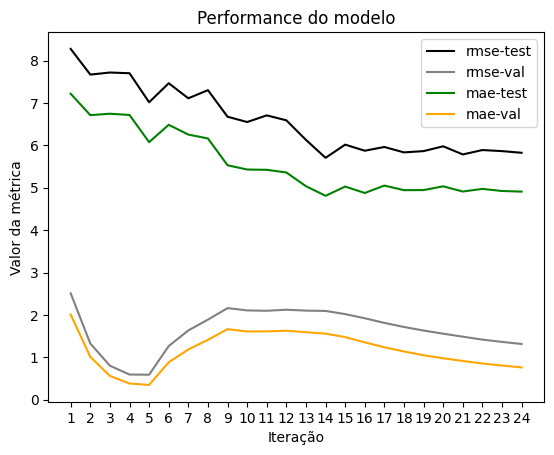

In [27]:
plt.plot(range(num_its),test_error_df['RMSE'], label="rmse-test", c='black')
plt.plot(range(num_its),exp_error_df['RMSE'], label="rmse-val", c='grey')
plt.plot(range(num_its),test_error_df['MAE'], label="mae-test", c="green")
plt.plot(range(num_its),exp_error_df['MAE'], label="mae-val", c="orange")
plt.xlabel("Iteração")
plt.ylabel("Valor da métrica")
plt.xticks(range(num_its), range(1, num_its+1))
plt.title("Performance do modelo")
plt.legend()
plt.show()

## Visualizando tempo de execução

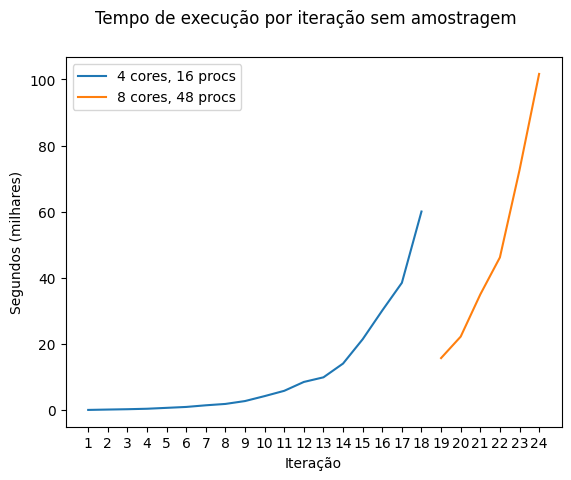

In [28]:
n_simple_its = 18
plt.plot(range(n_simple_its), times_df['seconds']/1000, label="4 cores, 16 procs")
fast_times_offset = len(times_df)
faster_length = len(times_f_df)
faster_x = [i+fast_times_offset for i in range(faster_length)]
plt.plot(faster_x, times_f_df['seconds']/1000, label="8 cores, 48 procs")
plt.ylabel("Segundos (milhares)")
plt.xlabel("Iteração")
plt.xticks(range(num_its), range(1, num_its+1))
plt.suptitle("Tempo de execução por iteração sem amostragem")
# plt.title("Com 4 cores e 16 processos por core", fontsize='medium', loc="left")
plt.legend()
plt.show()

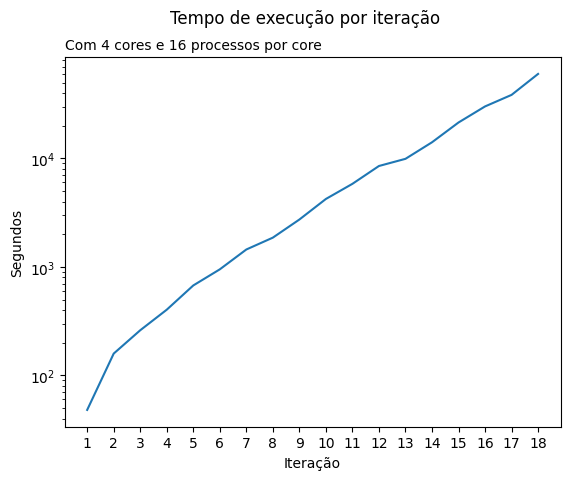

In [29]:
n_times_simple_its = min(num_its, len(times_df))
plt.plot(range(n_times_simple_its), times_df['seconds'])
plt.yscale("log")
plt.ylabel("Segundos")
plt.xlabel("Iteração")
plt.xticks(range(n_times_simple_its), range(1, n_times_simple_its+1))
plt.suptitle("Tempo de execução por iteração")
plt.title("Com 4 cores e 16 processos por core", fontsize='medium', loc="left")
plt.show()

### Comparando tempo de execução com quantidade de dados de treino

In [30]:
top_left_point = (0, 0)
bottom_right_point = (125, 250)
depth = 32
cube = ExplorationCube(top_left_point, bottom_right_point, depth)

In [31]:
wells_coords = [(34, 97), (98, 46), (55, 30), (101, 132), (33, 184)]

O último poço é o de teste então vamos tirá-lo da lista

In [32]:
wells_coords = wells_coords[:-1]
wells_coords

[(34, 97), (98, 46), (55, 30), (101, 132)]

In [33]:
for well_coord in wells_coords:
    cube.add_well_at(well_coord[0], well_coord[1])

In [34]:
num_predicted = list()
total_num_its = max(times_df['iteration'].max(), times_f_df['iteration'].max())
print(total_num_its)
for i in range(1, total_num_its+1):
    num_predicted.append(cube.num_predicted_at_it(i))
num_predicted = np.array(num_predicted)    

24


18


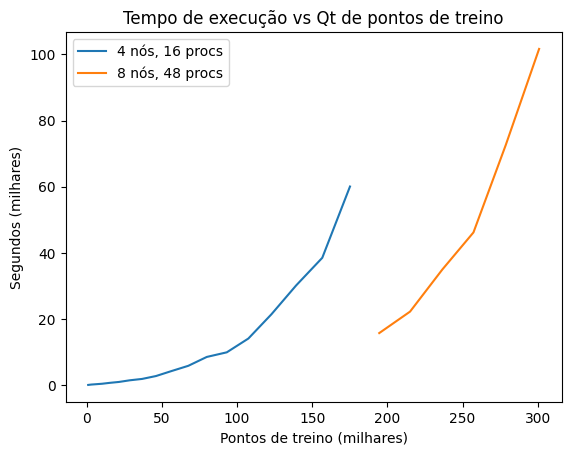

In [35]:
num_its_considered = len(times_df)
print(num_its_considered)
plt.plot(num_predicted[:num_its_considered]/1000, times_df['seconds']/1000, label="4 nós, 16 procs")
plt.plot(num_predicted[num_its_considered:]/1000, times_f_df['seconds']/1000, label="8 nós, 48 procs")
plt.xlabel("Pontos de treino (milhares)")
plt.ylabel("Segundos (milhares)")
plt.legend()
plt.title("Tempo de execução vs Qt de pontos de treino")
plt.show()

18


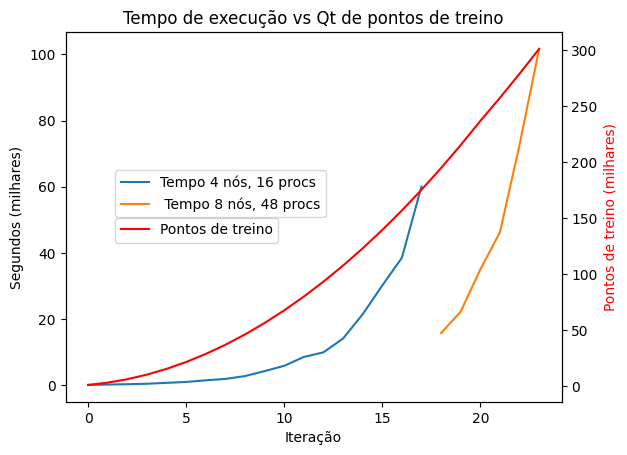

In [36]:

num_its_considered = len(times_df)
print(num_its_considered)
fast_times_offset = len(times_df)
faster_length = len(times_f_df)
faster_x = [i+fast_times_offset for i in range(faster_length)]
plt.plot(range(min(num_its, len(times_df))), times_df['seconds']/1000, label="Tempo 4 nós, 16 procs")
plt.plot(faster_x, times_f_df['seconds']/1000, label=" Tempo 8 nós, 48 procs")
plt.ylabel("Segundos (milhares)")
plt.xlabel("Iteração")

legend_x_pctg = 0.10
plt.legend(loc=(legend_x_pctg, 0.5))

axes2 = plt.twinx()
plt.ylabel("Num pontos de treino")
plt.plot(num_predicted/1000, label="Pontos de treino", c='red')
axes2.set_ylabel('Pontos de treino (milhares)', c='red')

plt.legend(loc=(legend_x_pctg, 0.43))
plt.title("Tempo de execução vs Qt de pontos de treino")
plt.show()

## Visualizando as features escolhidas

In [37]:
# feats_df = pd.DataFrame()
# feats_df.columns = [f"feat-{i}" for i in range(1, 11)]
feats_dict = exp_error_df.features.to_dict()
# print(feats_dict)
for i in range(len(feats_dict)):
    it_feats = feats_dict[i]
    feats_list = it_feats.split(",")
    feats_list = [feat.strip() for feat in feats_list]
    missing_feats = 10 - len(feats_list)
    if missing_feats > 0:
        print(f"It: {i}, N_feats: {len(feats_list)}, Missing: {missing_feats}")
        feats_list.extend([None]*missing_feats)
    
    feats_dict[i] = feats_list

It: 9, N_feats: 5, Missing: 5
It: 11, N_feats: 5, Missing: 5
It: 12, N_feats: 2, Missing: 8
It: 13, N_feats: 2, Missing: 8
It: 14, N_feats: 1, Missing: 9
It: 15, N_feats: 1, Missing: 9
It: 16, N_feats: 1, Missing: 9
It: 17, N_feats: 1, Missing: 9
It: 18, N_feats: 1, Missing: 9
It: 19, N_feats: 1, Missing: 9
It: 20, N_feats: 1, Missing: 9
It: 21, N_feats: 1, Missing: 9
It: 22, N_feats: 1, Missing: 9
It: 23, N_feats: 1, Missing: 9


In [38]:
def get_preffix(feat_name):
    if feat_name is not None:
        splitted = feat_name.split(" ")
        return splitted[0].split("_")[-3]
    return feat_name
    
def get_feat_preffix_series(feature_series):
    serie = feature_series.apply(get_preffix)
    return serie

feats_df = pd.DataFrame.from_dict(feats_dict, orient='index')
feats_df = feats_df.apply(get_feat_preffix_series)
feats_df.columns = [f"feat-{i}" for i in range(1, 11)]

In [39]:
feats_df.head()

,feat-1,feat-2,feat-3,feat-4,feat-5,feat-6,feat-7,feat-8,feat-9,feat-10
0,envelope,envelope,dip-angle,dip-angle,curvedness,mean-curvature,contur-curvature,most-negative-curvature,rms-3,most-positive-curvature
1,envelope,envelope,dip-angle,dip-angle,curvedness,most-positive-curvature,rms-3,dip-curvature,contur-curvature,contur-curvature
2,envelope,envelope,dip-angle,dip-angle,curvedness,rms-3,most-positive-curvature,contur-curvature,dip-curvature,max-curvature
3,envelope,envelope,dip-angle,dip-angle,curvedness,rms-3,most-positive-curvature,contur-curvature,dip-curvature,dip-curvature
4,envelope,envelope,dip-angle,dip-angle,curvedness,rms-3,most-positive-curvature,contur-curvature,dip-curvature,rms-5


In [40]:
feature_points = dict()

for row_idx, row in feats_df.iterrows():
    col_idx = 0
    for feature in row:
        if feature is not None:
            feat_points = feature_points.setdefault(feature, [[],[]])
            feat_points[0].append(row_idx+1)
            feat_points[1].append(col_idx+1)
        col_idx +=1

In [41]:
for key, value in list(feature_points.items())[:5]:
    print(f"{key}: \n{value[0]}, \n{value[1]}\n")

envelope: 
[1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 11, 11, 11, 11, 12, 12, 13, 13, 14, 14, 15, 16, 18, 20, 22, 23], 
[1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 8, 1, 2, 8, 9, 1, 2, 7, 10, 1, 2, 3, 9, 1, 2, 3, 1, 2, 3, 10, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1]

dip-angle: 
[1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 8, 11], 
[3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 9, 3, 5, 3, 6, 8, 7]

curvedness: 
[1, 2, 3, 4, 5, 6, 7, 8, 10], 
[5, 5, 5, 5, 5, 5, 4, 4, 4]

mean-curvature: 
[1, 10], 
[6, 5]

contur-curvature: 
[1, 2, 2, 3, 4, 5], 
[7, 9, 10, 8, 8, 8]



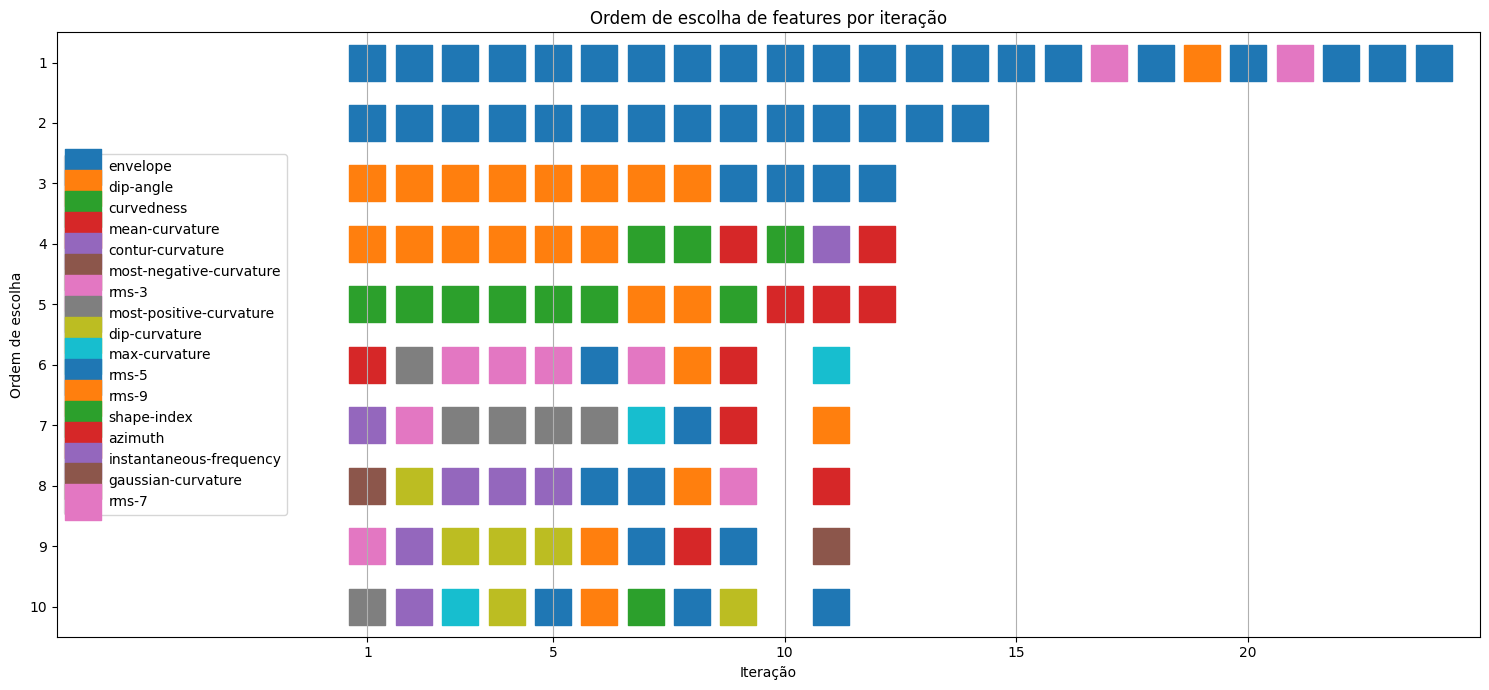

In [42]:
plt.figure(figsize=(15, 7))

for feat_name, (it_values, rank_values) in feature_points.items():
    num_points = len(it_values)
    plt.scatter(it_values, rank_values, marker='s', s=650, label=feat_name)##, mfc="w")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, num_its+1)
plt.yticks([rank for rank in range(1, 11)])
x_tick_step = 5
plt.xticks([1]+[it for it in range(5, num_its+1, x_tick_step)])
plt.grid(axis="x")
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
# plt.show()
plt.savefig("features_per_it_ANP_full.jpg")